## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

### Name: Tanim choudhury

**DUE: October 10, 2026 via D2L**

## Instructions:

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

- The purpose of this analysis is to determine whether the main tap station is operating in a state of statistical control, and if so, whether it is capable of consistently pouring liquid within the specification limits.

### Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.

- The QC is pour volume, measured in oz, which is a continuous random variable measured on a ratio scale.

### Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts?
- The general manager specified a concern ,"a small, sustained drift, rather than a sudden jump." which both CUSUM & EWWA are designed for catch small shifts. Whereas traditional Shewhart Charts are designed for large shifts .  
- A limitation of the CUSUM & EWMA chart is it is hard to siginal a large shift like Shewhart charts.
- Another is that for cusum it is more complex to implement & interpret such as tracking an exact moment. You have to track the accumulation. Also it is as less obvious to set the H & K parameters compared to Shewhart parameters.
- For EWMA chart it needs independence of observations. Otherwise it could lead to issues of false alarm rates(sensitive to small shifts) or tiny alarm rates(insensitive to real shifts)
## Analyze

### Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

In [1]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "tchoud227"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}

# Change the working directory to the specific assignment folder within the cloned repository
setwd(file.path(repo_name, "Assignments", "HW2"))

[1] "Repository already cloned to Colab."


In [2]:
getwd()

[1] "/content/STAT-7110-Quality-Control/Assignments/HW2"

In [3]:
install.packages(c("tidyverse", "readxl", "qcc"))

library(tidyverse)
library(readxl)
library(qcc)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



In [4]:
## Q4 Code ##
Bar_p1 <- read_excel("BustersSportsBar_PhaseI.xlsx")
Bar_p1 |> glimpse()

Rows: 25
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0413, 16.0675, 16.0556, 16.0424, 15.9992, 16.0585, 16.1422, 1…
$ Pour2 <dbl> 16.1330, 16.0046, 15.9970, 16.1595, 15.9692, 16.1351, 16.1080, 1…
$ Pour3 <dbl> 16.2208, 16.0829, 16.0578, 16.1260, 16.0182, 15.9698, 16.0274, 1…
$ Pour4 <dbl> 15.9739, 16.0750, 16.0771, 15.9804, 15.9541, 15.9335, 15.9874, 1…
$ Pour5 <dbl> 16.0762, 16.0499, 16.0694, 16.0306, 15.9968, 16.0919, 16.0022, 1…


In [5]:
#drop subgroup
Bar_p1 <- Bar_p1 |> select(-Shift)

In [6]:
#report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation
xbar_p1 <- qcc(Bar_p1, type = "xbar", plot = FALSE, std.dev="UWAVE-SD")
r_p1 <- qcc(Bar_p1, type = "R", plot = FALSE)

#subgroup means & ranges
sg_mean <- xbar_p1$statistics
sg_range <- r_p1$statistics

cat("subgroup means: \n", round(sg_mean,4))


cat("\n\n subgroup range: \n", round(sg_range,4))


subgroup means: 
 16.089 16.056 16.0514 16.0678 15.9875 16.0378 16.0534 16.0952 16.0668 16.0482 16.0458 15.7078 16.0786 16.0621 16.0064 16.0415 16.0551 16.0831 15.9957 16.0205 16.1008 16.0255 16.0923 16.0351 16.0605

 subgroup range: 
 0.2469 0.0783 0.0801 0.1791 0.0641 0.2016 0.1548 0.2202 0.1927 0.0942 0.12 0.2178 0.1995 0.1993 0.1643 0.1941 0.118 0.1488 0.6818 0.0912 0.0724 0.1377 0.2165 0.2231 0.1919

In [7]:
#estimate process mean & std
process_mean <- xbar_p1$center
cat("Process Mean: \n", process_mean)
process_std <- xbar_p1$std.dev
cat("\n\n Process std: \n", process_std)

Process Mean: 
 16.03856

 Process std: 
 0.07532586

### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

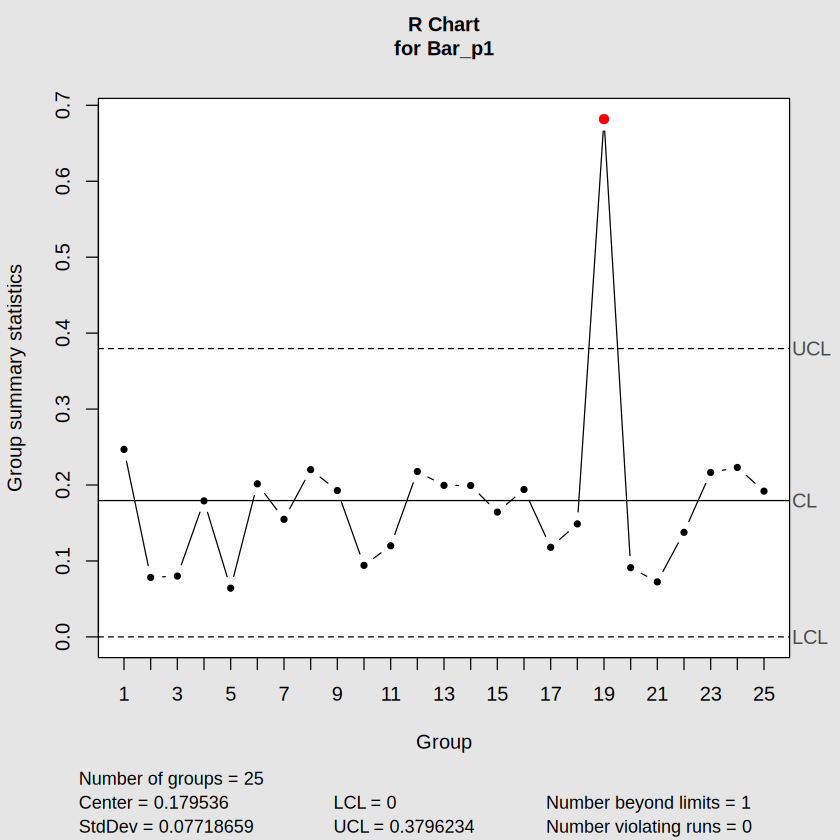

In [8]:
## Q5 Code ##
r_chart <- qcc(Bar_p1, type = "R", plot = TRUE)

No evidence of statistical control. We see that shift 19 is where a point was above the upper control limit. However it was just that single- spike, and no observable trend. This could be from a beer line issue or maybe the aging regulator.

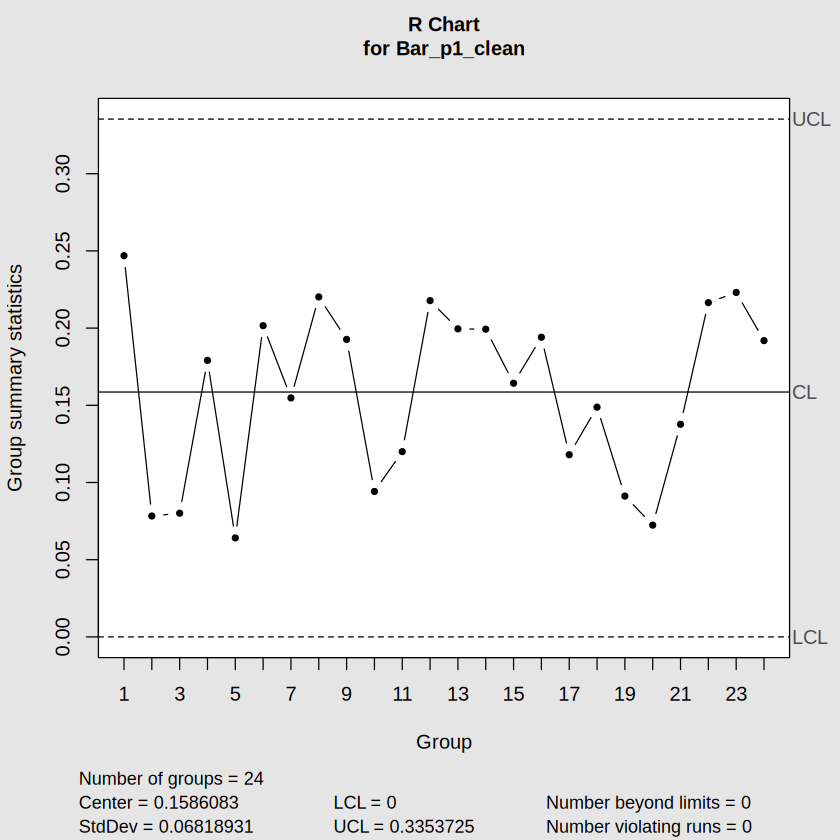

In [9]:
#omitting shift 19
Bar_p1_clean <- Bar_p1 |> slice(-19)
r_chart_clean <- qcc(Bar_p1_clean, type = "R", plot = TRUE)

No violation!

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

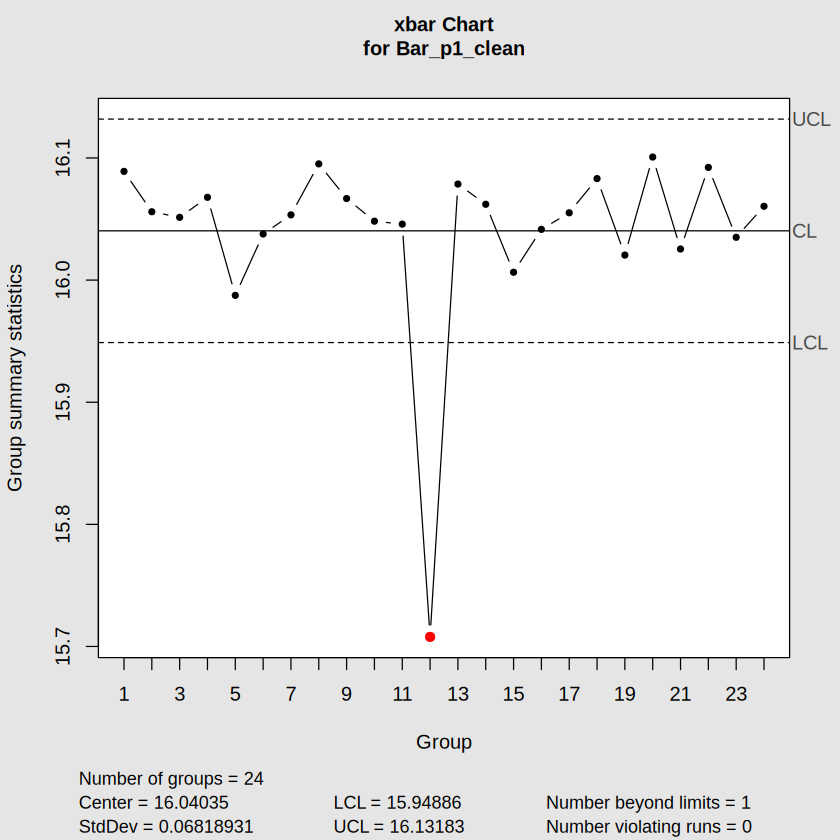

In [10]:
## Q6 Code ##
xbar_chart <- qcc(Bar_p1_clean, type = "xbar", plot = TRUE)

No evidence of statistical control. We see that shift 12 is where a point was below the lower control limit. However it was just that single- spike, and no observable trend. This could be from a beer line issue or maybe the aging regulator.

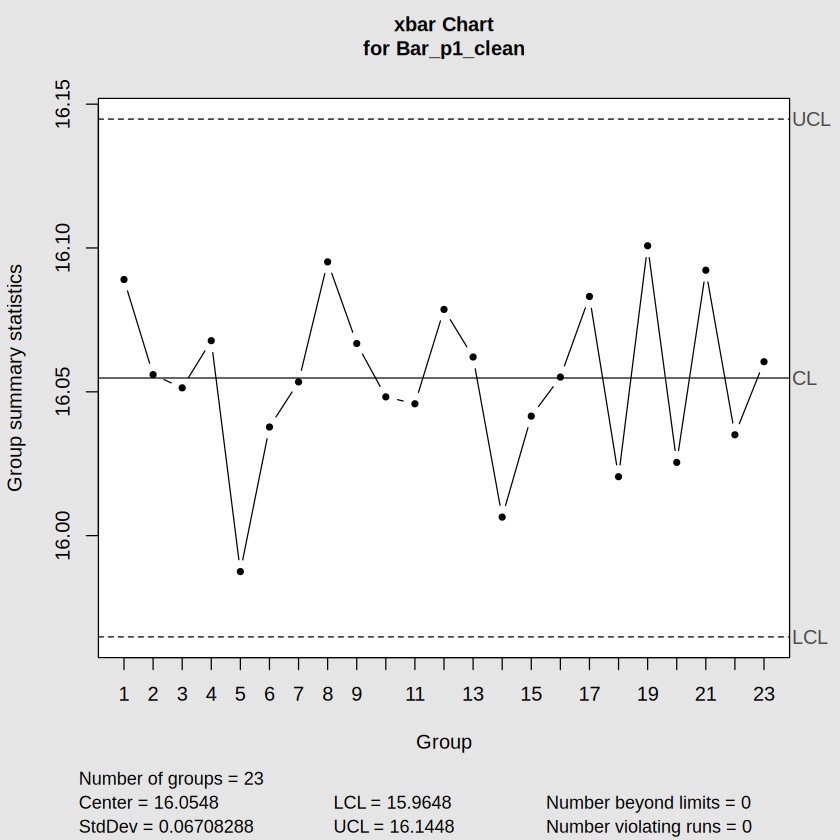

In [11]:
#omitting shift 12
Bar_p1_clean <- Bar_p1_clean |> slice(-12)
xbar_chart_clean <- qcc(Bar_p1_clean, type = "xbar", plot = TRUE)

No violation!

### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

In [12]:
## Q7 Code ##
## Specify Limits ##

USL <- 16.2
LSL <- 15.8
target <- 16.0

process_mean <- xbar_chart_clean$center
process_sd <- xbar_chart_clean$std.dev

## FNC ##

fnc <- pnorm(LSL, mean = process_mean, sd = process_sd) +
  1 - pnorm(USL, mean = process_mean, sd = process_sd)

## Cp ##

cp <- (USL - LSL) / (6 * process_sd)

## Cpk ##

cpk <- min((USL - process_mean) / (3 * process_sd),
           (process_mean - LSL) / (3 * process_sd))

## Cpm ##

cpm <- (USL - LSL) / (6 * sqrt(process_sd^2 + (process_mean - target)^2))

### Output Results ##

cat("Process Capability Analysis Results:\n")
cat("FNC:", fnc, "\n")
cat("Defects per Million Opportunities (DPMO):", fnc * 1e6, "\n")
cat("Cp:", cp, "\n")
cat("Cpk:", cpk, "\n")
cat("Cpm:", cpm, "\n")

Process Capability Analysis Results:
FNC: 0.01528784 
Defects per Million Opportunities (DPMO): 15287.84 
Cp: 0.9937955 
Cpk: 0.7214826 
Cpm: 0.7696239 


- The FNC value of 1.53% of the pints poured during phase 1 failed the key specifications. With the DPMO it suggests that approximately 15 out of 1000 pints are improperly poured.
The Cp, Cpk, & Cpm is less than 1 which suggests that process is not capable.
- Overall, the process is not capapble in meeting specification.
- The process is not well-centered.


## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

- (a) To use the ARL table for cusum from lecture the slack value k need to be 1/2. As for the decision interval h = 5 would be best since the Manager specifiec a in-control ARL around 370 - 500 which is valid for h = 5's 465 versus h = 4's 168.

- (b) The manager specified a detection of one process standard deviation. From looking in the ARL for EWWA, we see the comibnation of L & lambda [2.814, 0.1] would detect shifts the fastest for a shift of 1 std.  
## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q9, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

Rows: 20
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0792, 16.0338, 16.0122, 16.0267, 16.0398, 16.0597, 16.0523, 1…
$ Pour2 <dbl> 16.1017, 16.0037, 16.0499, 16.0925, 16.1340, 16.1104, 16.0450, 1…
$ Pour3 <dbl> 16.1325, 16.0427, 16.1096, 15.8856, 16.0590, 16.0148, 16.0159, 1…
$ Pour4 <dbl> 16.0593, 15.9930, 16.0066, 16.1227, 16.1007, 15.9631, 16.0345, 1…
$ Pour5 <dbl> 16.0851, 16.0053, 16.0047, 15.9553, 16.0776, 16.1903, 16.0249, 1…


List of 14
 $ call             : language cusum(data = Bar_p2, sizes = 5, center = process_mean, std.dev = process_sd,      decision.interval = H, se.shift| __truncated__
 $ type             : chr "cusum"
 $ data.name        : chr "Bar_p2"
 $ data             : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes            : num [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center           : num 16.1
 $ std.dev          : num 0.0671
 $ pos              : num [1:20] 0 0 0 0 0 0 0 0 0 0 ...
 $ neg              : num [1:20] -82.1 -160.8 -233.3 -300.8 -361 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

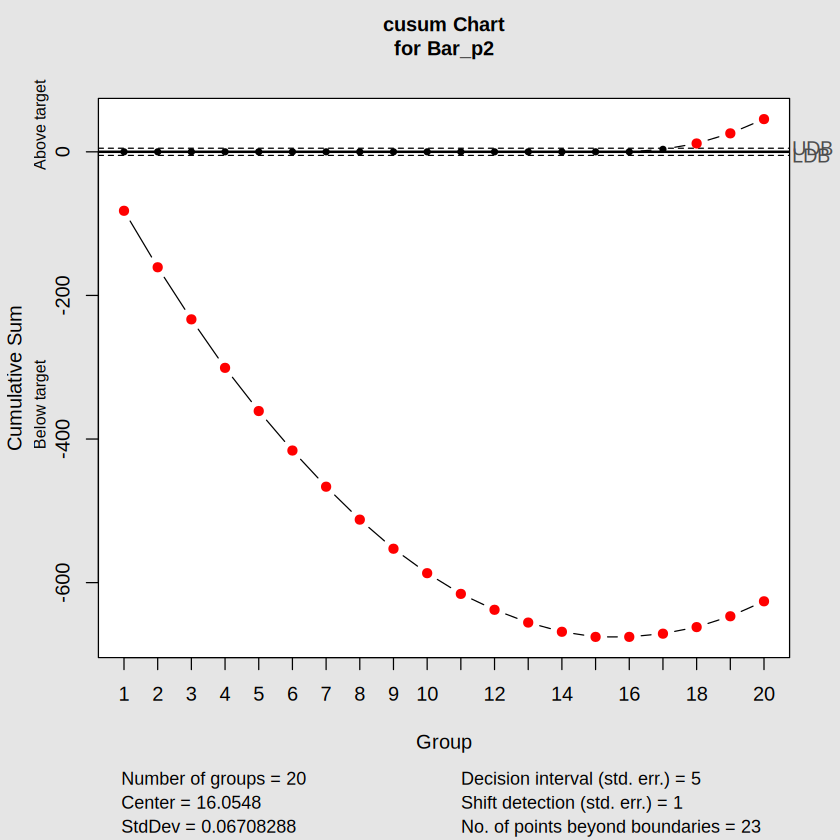

In [13]:
## Q9 Code ##
K <- 0.5
H <- 5

Bar_p2 <- read_excel("BustersSportsBar_PhaseII.xlsx")
Bar_p2 |> glimpse()

cusum(Bar_p2, sizes = 5, center = process_mean, std.dev = process_sd, se.shift = K *2, decision.interval = H, plot = T)

The cusum chart signals out of control condition:
- all 20 groups are flagged as out of control.
- The first shift is at the start, shift 1.

### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

List of 15
 $ call      : language ewma(data = Bar_p2, center = process_mean, std.dev = process_sd, lambda = lambda,      nsigmas = L)
 $ type      : chr "ewma"
 $ data.name : chr "Bar_p2"
 $ data      : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 6 6 6 6 6 6 6 6 6 6 ...
 $ center    : num 16.1
 $ std.dev   : num 0.0671
 $ x         : int [1:20] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:20] 15.8 15.6 15.4 15.3 15.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sigma     : num [1:20] 0.00274 0.00368 0.0043 0.00474 0.00507 ...
 $ lambda    : num 0.1
 $ nsigmas   : num 2.81
 $ limits    : num [1:20, 1:2] 16 16 16 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int [1:20] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 - attr(*, "class")= chr

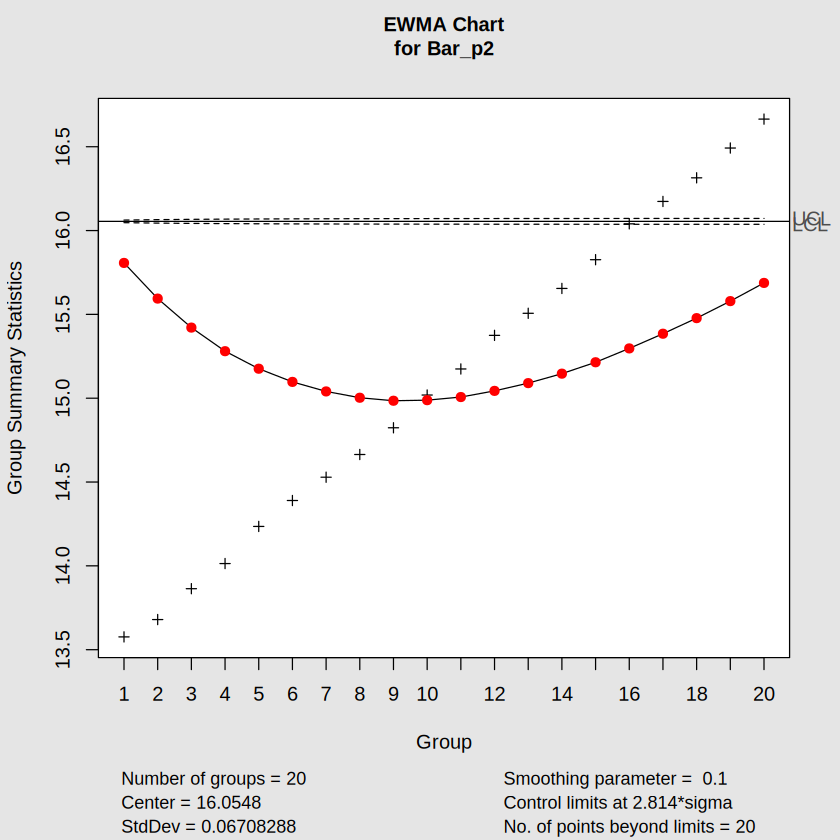

In [14]:
## Q10 Code ##
lambda <- 0.1
L <- 2.814
ewma(Bar_p2,center= process_mean, std.dev = process_sd, lambda= lambda,nsigmas=L)


The EWMA chart also signals aout of control condition:
- Also 20 groups are flagged as out of control.
- Again, starting in the first shift.

### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

- Neither chart detected the shift more quickly they both siginaled at shift 1.
- It is what I expect in that the chosen parameters for the charts both have very similar expected run length. CUSUM ARL being 10.4 & EWMA being 10.3 are pretty close. Hence my expectation of similar outcomes.
- As for the shift detection,  we saw that it was not a gradual shift but an instant shift from shift 1. This is a expeceted behavior for charts designed for small shifts in mind.

### Q13: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?

# Overview of Results:
- **Phase 1 findings**: 2 groups where found to have issue that violated statistical control. Observations 19 & 12. However, it was just that single- spike, and no observable trend. This could be from a beer line issue or maybe the aging regulator.
- The FNC suggest that for every 1000 pints. 15 will be out of pour specification.
- Overall, the process is not capapble in meeting specification in regards to Cp, Cpk, & Cpm.
- The process is not well-centered.
-  **Phase 2 findings:** Both CUSUM & EWMA chart signaled out of control condition from shift 1 and flagged the rest of the monitored shifts. Those monitored shifts are significantly below the lower specification limit of 15.8 oz which is a problem.
- **Recommendation:** It is highly suggested to replace the aging C02 regulator immediately. Otherwise this will leave customer continued satisfaction with pours being siginficantly less than the target and LSL value. After getting the replacemnet, the phase 2 charts should rerun to ensure stastical control within the key specification.